Starting Data Analysis Pipeline...
Dataset Shape: 1565 rows × 18 columns

Data Types:
object    18
Name: count, dtype: int64

Memory Usage: 1.7580013275146484 MB

DATA QUALITY REPORT

1. MISSING VALUE ANALYSIS
----------------------------------------
Top 15 columns with missing values:
             column_name  missing_count  missing_percentage data_type
        Appointment_Date           1192           76.166134    object
                 Remarks            748           47.795527    object
 Application_Agency_Code            344           21.980831    object
          Contact_Number             34            2.172524    object
     Program_Of_interest              0            0.000000    object
          Student_Status              0            0.000000    object
   Citizenship_(Primary)              0            0.000000    object
            I_901_Status              0            0.000000    object
Person_SLU_Email_Address              0            0.000000    object
       Studen

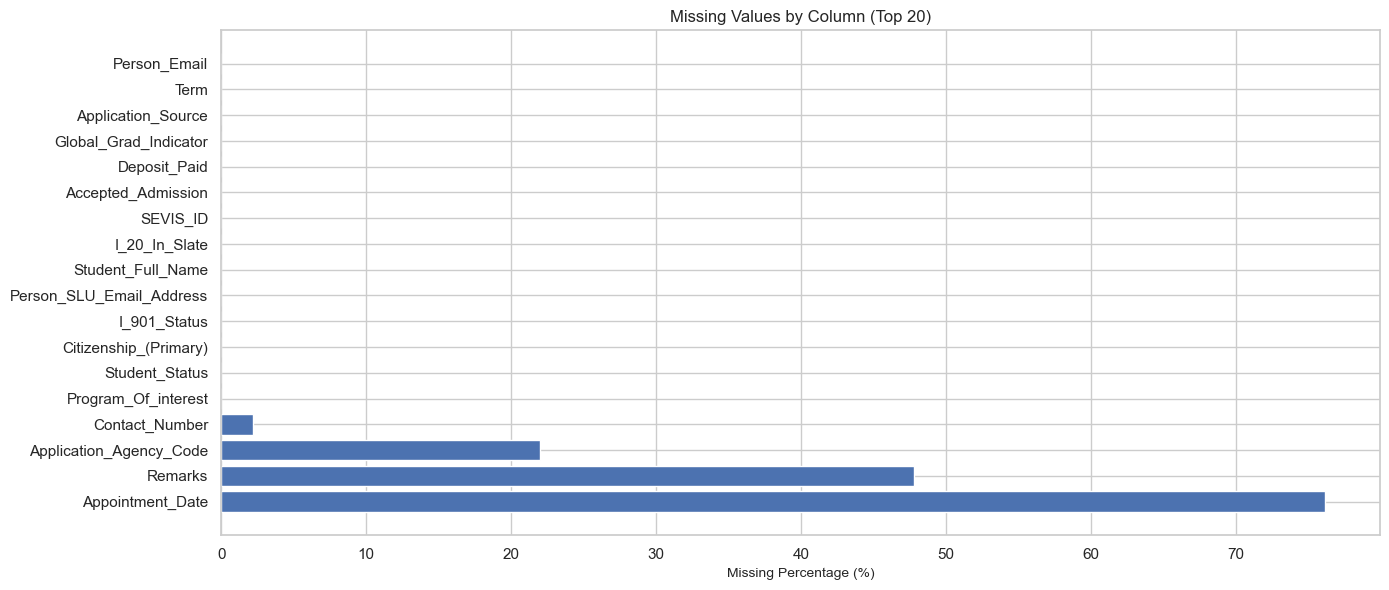


2. DUPLICATE RECORD ANALYSIS
----------------------------------------
Complete duplicate rows: 0 (0.00%)

3. DATA TYPE CONSISTENCY CHECK
----------------------------------------
Columns with potential mixed data types: ['SEVIS_ID', 'Contact_Number']

4. PRELIMINARY DATA ISSUES
----------------------------------------
Placeholder values found:
  '-': 1 occurrences

INITIAL EXPLORATORY DATA ANALYSIS

1. BASIC STATISTICS
----------------------------------------
Numeric columns (0): []
Categorical columns (18): ['Student_Full_Name', 'Program_Of_interest', 'Term', 'Application_Source', 'Global_Grad_Indicator', 'Deposit_Paid', 'Accepted_Admission', 'SEVIS_ID', 'I_20_In_Slate', 'Person_Email']...

2. CATEGORICAL VARIABLES OVERVIEW
----------------------------------------
Unique values in categorical columns (first 10):
                       unique_count
Term                              2
Global_Grad_Indicator             2
Deposit_Paid                      2
Accepted_Admission             

In [1]:
# ============================================================================
# COMPREHENSIVE DATA ANALYSIS REPORT GENERATOR
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# ============================================================================
# 1. DATA LOADING AND INITIAL INSPECTION
# ============================================================================

def load_and_inspect_data(filepath):
    """Load CSV file and perform initial inspection"""
    try:
        # Try different encodings if needed
        try:
            df = pd.read_csv(filepath, encoding='utf-8')
        except UnicodeDecodeError:
            df = pd.read_csv(filepath, encoding='latin1')
        
        df.head(5)
        
        
        print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
       
        print("\nData Types:")
        print(df.dtypes.value_counts())
        print("\nMemory Usage:", df.memory_usage(deep=True).sum() / 1024 / 1024, "MB")
        
        return df
    except Exception as e:
        print(f"Error loading file: {e}")
        return None

# ============================================================================
# 2. DATA QUALITY REPORT FUNCTIONS
# ============================================================================

def generate_data_quality_report(df):
    """Generate comprehensive data quality report"""
    
    print("\n" + "=" * 80)
    print("DATA QUALITY REPORT")
    print("=" * 80)
    
    # --------------------------------------------------------------------
    # 2.1 Missing Value Analysis
    # --------------------------------------------------------------------
    print("\n1. MISSING VALUE ANALYSIS")
    print("-" * 40)
    
    missing_data = pd.DataFrame({
        'column_name': df.columns,
        'missing_count': df.isnull().sum().values,
        'missing_percentage': (df.isnull().sum() / len(df) * 100).values,
        'data_type': df.dtypes.values
    })
    
    missing_data = missing_data.sort_values('missing_percentage', ascending=False)
    
    # Display top columns with missing values
    print("Top 15 columns with missing values:")
    print(missing_data.head(15).to_string(index=False))
    
    # Summary statistics
    print(f"\nMissing Value Summary:")
    print(f"Total missing cells: {df.isnull().sum().sum():,}")
    print(f"Average missing percentage: {missing_data['missing_percentage'].mean():.2f}%")
    print(f"Columns with >50% missing: {(missing_data['missing_percentage'] > 50).sum()}")
    print(f"Columns with >90% missing: {(missing_data['missing_percentage'] > 90).sum()}")
    
    # Visualize missing data
    plt.figure(figsize=(14, 6))
    top_missing = missing_data.head(20)
    plt.barh(top_missing['column_name'], top_missing['missing_percentage'])
    plt.xlabel('Missing Percentage (%)')
    plt.title('Missing Values by Column (Top 20)')
    plt.tight_layout()
    plt.show()
    
    df = df.drop(['Appointment_Date'], axis=1)
    
    # --------------------------------------------------------------------
    # 2.2 Duplicate Record Analysis
    # --------------------------------------------------------------------
    print("\n2. DUPLICATE RECORD ANALYSIS")
    print("-" * 40)
    
    # Full duplicate rows
    duplicate_rows = df.duplicated().sum()
    duplicate_percentage = (duplicate_rows / len(df)) * 100
    
    print(f"Complete duplicate rows: {duplicate_rows} ({duplicate_percentage:.2f}%)")
    
    # Check for duplicates in key identifier columns
    id_columns = []
    for col in ['id', 'ID', 'Id', 'email', 'Email', 'student_id', 'Student_ID', 'SEVIS']:
        if col in df.columns:
            id_columns.append(col)
    
    if id_columns:
        print(f"\nChecking duplicates in potential ID columns: {id_columns}")
        for col in id_columns:
            if col in df.columns:
                dup_count = df[col].duplicated().sum()
                unique_count = df[col].nunique()
                print(f"  {col}: {dup_count} duplicates, {unique_count} unique values")
    
    # --------------------------------------------------------------------
    # 2.3 Data Type Consistency Check
    # --------------------------------------------------------------------
    print("\n3. DATA TYPE CONSISTENCY CHECK")
    print("-" * 40)
    
    # Check for mixed data types
    problematic_cols = []
    for col in df.columns:
        if df[col].dtype == 'object':
            # Check if column has mixed numeric and string values
            numeric_count = pd.to_numeric(df[col], errors='coerce').notna().sum()
            if 0 < numeric_count < len(df):
                problematic_cols.append(col)
    
    if problematic_cols:
        print(f"Columns with potential mixed data types: {problematic_cols}")
    else:
        print("No obvious mixed data type issues detected.")
    
    # --------------------------------------------------------------------
    # 2.4 Preliminary Data Issues
    # --------------------------------------------------------------------
    print("\n4. PRELIMINARY DATA ISSUES")
    print("-" * 40)
    
    # Check for placeholder/error values
    placeholder_indicators = ['NA', 'N/A', 'NULL', 'None', 'nan', 'NaN', '-', '--', '___']
    
    placeholder_counts = {}
    for indicator in placeholder_indicators:
        count = (df == indicator).sum().sum()
        if count > 0:
            placeholder_counts[indicator] = count
    
    if placeholder_counts:
        print("Placeholder values found:")
        for key, value in placeholder_counts.items():
            print(f"  '{key}': {value} occurrences")
    else:
        print("No common placeholder values detected.")
    
    return missing_data

# ============================================================================
# 3. INITIAL EDA FUNCTIONS (First Round)
# ============================================================================

def initial_eda(df):
    """Perform initial exploratory data analysis"""
    
    print("\n" + "=" * 80)
    print("INITIAL EXPLORATORY DATA ANALYSIS")
    print("=" * 80)
    
    # --------------------------------------------------------------------
    # 3.1 Basic Statistics
    # --------------------------------------------------------------------
    print("\n1. BASIC STATISTICS")
    print("-" * 40)
    
    # Separate numeric and categorical columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    
    print(f"Numeric columns ({len(numeric_cols)}): {numeric_cols[:10]}{'...' if len(numeric_cols) > 10 else ''}")
    print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols[:10]}{'...' if len(categorical_cols) > 10 else ''}")
    
    # Summary statistics for numeric columns
    if numeric_cols:
        print("\nNumeric Columns Summary:")
        print(df[numeric_cols].describe().T.round(2))
    
    # --------------------------------------------------------------------
    # 3.2 Categorical Variables Overview
    # --------------------------------------------------------------------
    print("\n2. CATEGORICAL VARIABLES OVERVIEW")
    print("-" * 40)
    
    if categorical_cols:
        # Show unique values for categorical columns
        unique_counts = {}
        for col in categorical_cols[:10]:  # Limit to first 10 for initial view
            unique_vals = df[col].nunique()
            unique_counts[col] = unique_vals
        
        unique_df = pd.DataFrame.from_dict(unique_counts, orient='index', columns=['unique_count'])
        unique_df = unique_df.sort_values('unique_count')
        
        print("Unique values in categorical columns (first 10):")
        print(unique_df.to_string())
        
        # Visualize high cardinality columns
        high_card_cols = unique_df[unique_df['unique_count'] > 50].index.tolist()
        if high_card_cols:
            print(f"\nHigh cardinality columns (>50 unique values): {high_card_cols}")
    
    # --------------------------------------------------------------------
    # 3.3 Initial Visualizations
    # --------------------------------------------------------------------
    print("\n3. INITIAL VISUALIZATIONS")
    print("-" * 40)
    
    # Create subplots for initial distributions
    if numeric_cols:
        # Plot distributions of numeric columns
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        axes = axes.flatten()
        
        for idx, col in enumerate(numeric_cols[:6]):
            if idx < len(axes):
                axes[idx].hist(df[col].dropna(), bins=30, alpha=0.7, edgecolor='black')
                axes[idx].set_title(f'Distribution of {col}')
                axes[idx].set_xlabel(col)
                axes[idx].set_ylabel('Frequency')
        
        plt.tight_layout()
        plt.suptitle('Initial Distribution of Numeric Columns', y=1.02, fontsize=14)
        plt.show()
    
    # --------------------------------------------------------------------
    # 3.4 Identify Potential Outliers
    # --------------------------------------------------------------------
    print("\n4. POTENTIAL OUTLIER DETECTION")
    print("-" * 40)
    
    if numeric_cols:
        outlier_info = {}
        for col in numeric_cols[:5]:  # Check first 5 numeric columns
            q1 = df[col].quantile(0.25)
            q3 = df[col].quantile(0.75)
            iqr = q3 - q1
            lower_bound = q1 - 1.5 * iqr
            upper_bound = q3 + 1.5 * iqr
            
            outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
            outlier_count = outliers.count()
            
            if outlier_count > 0:
                outlier_info[col] = {
                    'count': outlier_count,
                    'percentage': (outlier_count / len(df) * 100),
                    'min': df[col].min(),
                    'max': df[col].max()
                }
        
        if outlier_info:
            print("Potential outliers detected (using IQR method):")
            outlier_df = pd.DataFrame(outlier_info).T
            print(outlier_df)
        else:
            print("No significant outliers detected in first 5 numeric columns.")

# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    # Replace with your CSV file path
    csv_path = 'Copy of Outreach - Outreach_efforts.csv'  # Update this path
    
    print("Starting Data Analysis Pipeline...")
    print("=" * 80)
    
    # Step 1: Load and inspect data
    df = load_and_inspect_data(csv_path)
    
    if df is not None:
        # Step 2: Generate Data Quality Report
        missing_report = generate_data_quality_report(df)
        
        # Step 3: Perform Initial EDA
        initial_eda(df)
        
        print("\n" + "=" * 80)
        print("PHASE 1 COMPLETE")
        print("=" * 80)
        print("\nPlease provide the outputs above, and I'll help you with:")
        print("1. Detailed outlier analysis for specific columns")
        print("2. Correlation analysis and heatmaps")
        print("3. Advanced visualizations (boxplots, pairplots, etc.)")
        print("4. Pattern identification and insights")
        print("5. Report generation in proper format")


OUTLIER ANALYSIS

COMPREHENSIVE OUTLIER ANALYSIS

1. OUTLIERS IN TEXT LENGTH FIELDS
----------------------------------------

Name_Length:
  • Total values: 1565
  • Normal range: [4.0, 36.0]
  • Outliers detected: 84 (5.4%)
  • Outlier values: [37, 40, 41, 43, 45]

Email_Length:
  • Total values: 1565
  • Normal range: [15.5, 35.5]
  • Outliers detected: 30 (1.9%)
  • Outlier values: [36, 37, 38, 41, 42]

SEVIS_ID_Length:
  • Total values: 1565
  • Normal range: [11.0, 11.0]
  • Outliers detected: 1 (0.1%)
  • Outlier values: [7]

Contact_Length:
  • Total values: 1565
  • Normal range: [10.0, 10.0]
  • Outliers detected: 281 (18.0%)
  • Outlier values: [0, 9, 12, 13, 14]

2. VISUALIZATION OF OUTLIERS
----------------------------------------


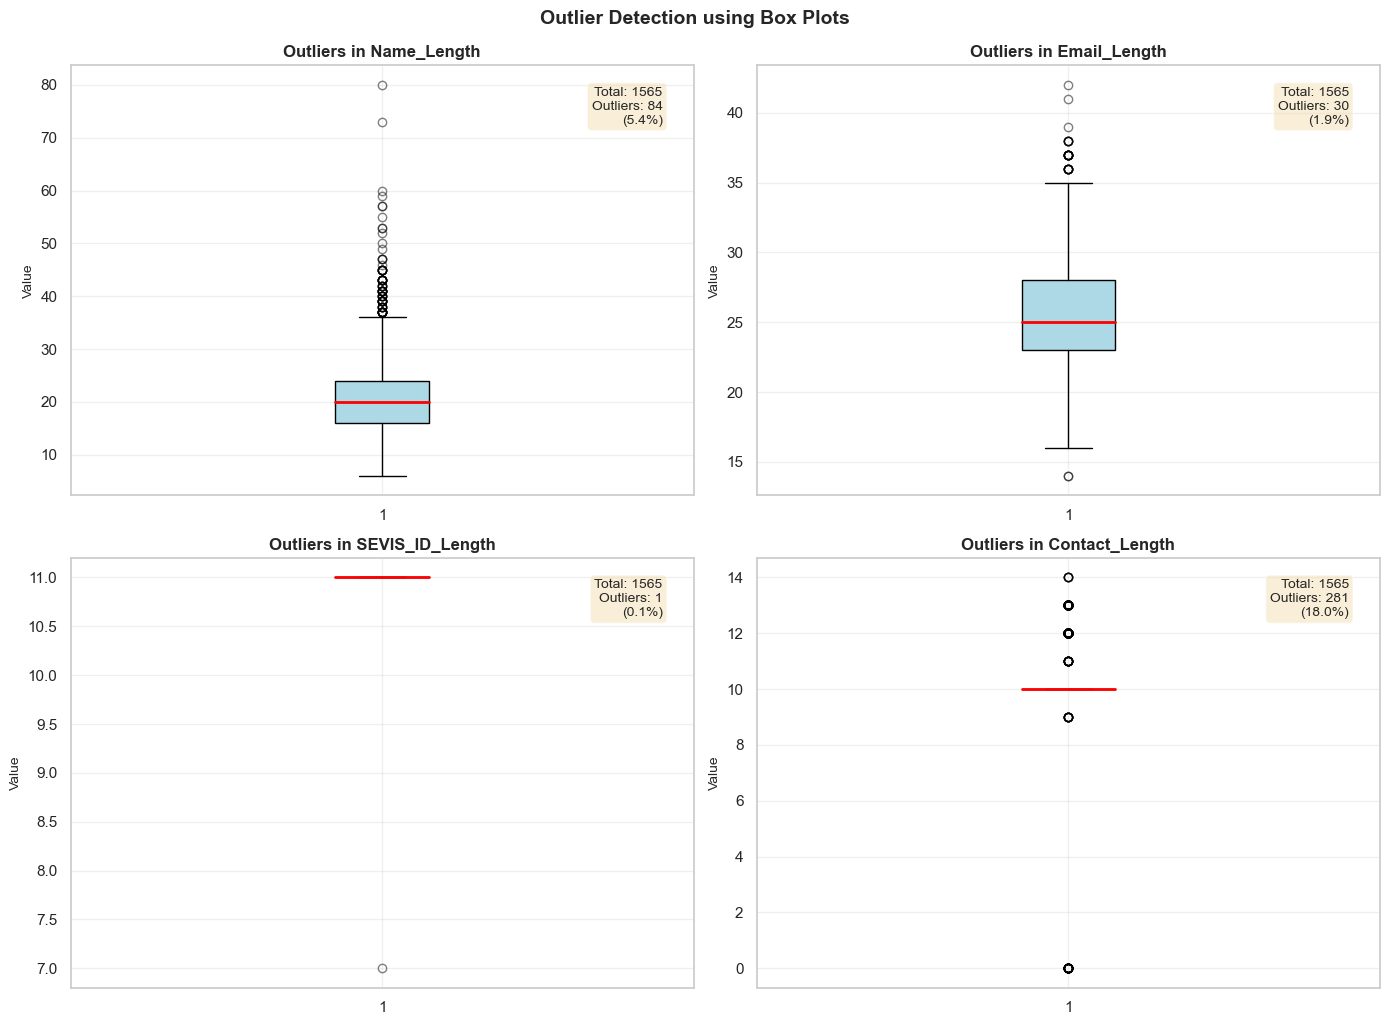


3. UNUSUAL CATEGORIES IN CATEGORICAL DATA
----------------------------------------

Program_Of_interest:
  • Total categories: 47
  • Rare categories (<1% frequency): 32
  • Top rare categories:
    - 'Computer Science (PhD)': 8 occurrences (0.51%)
    - 'Software Engineering (MS)': 8 occurrences (0.51%)
    - 'Communication (MA)': 7 occurrences (0.45%)

Citizenship_(Primary):
  • Total categories: 34
  • Rare categories (<1% frequency): 29
  • Top rare categories:
    - 'Nepal': 15 occurrences (0.96%)
    - 'Bangladesh': 13 occurrences (0.83%)
    - 'Kenya': 13 occurrences (0.83%)

Application_Source:
  • Total categories: 7
  • Rare categories (<1% frequency): 4
  • Top rare categories:
    - 'SOPHAS': 11 occurrences (0.70%)
    - 'CollegeNet': 8 occurrences (0.51%)
    - 'Element': 2 occurrences (0.13%)

4. CONTACT NUMBER VALIDITY ANALYSIS
----------------------------------------
Contact Number Length Distribution:
  • 0 digits: 37 numbers (2.4%) ✗ UNUSUAL
  • 9 digits: 10 numbers 

In [2]:
# ============================================================================
# 4. OUTLIER ANALYSIS SECTION
# ============================================================================

def analyze_outliers(df):
    """Comprehensive outlier analysis for all data types"""
    
    print("\n" + "=" * 80)
    print("COMPREHENSIVE OUTLIER ANALYSIS")
    print("=" * 80)
    
    # Create helper columns for outlier detection
    df = create_outlier_analysis_columns(df)
    
    # --------------------------------------------------------------------
    # 4.1 Outliers in Text Length Fields
    # --------------------------------------------------------------------
    print("\n1. OUTLIERS IN TEXT LENGTH FIELDS")
    print("-" * 40)
    
    length_columns = ['Name_Length', 'Email_Length', 'SEVIS_ID_Length', 'Contact_Length']
    
    for col in length_columns:
        if col in df.columns:
            data = df[col].dropna()
            if len(data) > 0:
                Q1 = data.quantile(0.25)
                Q3 = data.quantile(0.75)
                IQR = Q3 - Q1
                lower_bound = Q1 - 1.5 * IQR
                upper_bound = Q3 + 1.5 * IQR
                
                outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
                outlier_count = len(outliers)
                outlier_percentage = (outlier_count / len(df)) * 100
                
                print(f"\n{col}:")
                print(f"  • Total values: {len(data)}")
                print(f"  • Normal range: [{lower_bound:.1f}, {upper_bound:.1f}]")
                print(f"  • Outliers detected: {outlier_count} ({outlier_percentage:.1f}%)")
                if outlier_count > 0:
                    print(f"  • Outlier values: {sorted(outliers[col].unique().tolist()[:5])}")
    
    # --------------------------------------------------------------------
    # 4.2 Visualize Outliers with Box Plots
    # --------------------------------------------------------------------
    print("\n2. VISUALIZATION OF OUTLIERS")
    print("-" * 40)
    
    # Create box plots for length columns
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    for idx, col in enumerate(length_columns):
        if col in df.columns and idx < 4:
            ax = axes[idx]
            box_data = df[col].dropna()
            
            if len(box_data) > 0:
                # Create boxplot
                bp = ax.boxplot(box_data, vert=True, patch_artist=True, 
                               boxprops=dict(facecolor='lightblue'),
                               medianprops=dict(color='red', linewidth=2),
                               whiskerprops=dict(color='black'),
                               capprops=dict(color='black'),
                               flierprops=dict(marker='o', color='red', alpha=0.5))
                
                # Calculate outlier statistics
                Q1 = box_data.quantile(0.25)
                Q3 = box_data.quantile(0.75)
                IQR = Q3 - Q1
                lower_bound = Q1 - 1.5 * IQR
                upper_bound = Q3 + 1.5 * IQR
                outliers = box_data[(box_data < lower_bound) | (box_data > upper_bound)]
                
                # Add text with statistics
                stats_text = f"Total: {len(box_data)}\nOutliers: {len(outliers)}\n({(len(outliers)/len(box_data)*100):.1f}%)"
                ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, 
                       verticalalignment='top', horizontalalignment='right',
                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
                
                ax.set_title(f'Outliers in {col}', fontsize=12, fontweight='bold')
                ax.set_ylabel('Value')
                ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.suptitle('Outlier Detection using Box Plots', y=1.02, fontsize=14, fontweight='bold')
    plt.show()
    
    # --------------------------------------------------------------------
    # 4.3 Outliers in Categorical Data (Unusual Categories)
    # --------------------------------------------------------------------
    print("\n3. UNUSUAL CATEGORIES IN CATEGORICAL DATA")
    print("-" * 40)
    
    categorical_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
    
    # Focus on key categorical columns
    key_categorical = ['Student_Status', 'Program_Of_interest', 'Citizenship_(Primary)', 
                       'Application_Source', 'I_901_Status']
    
    for col in key_categorical:
        if col in df.columns:
            value_counts = df[col].value_counts()
            total = len(df[col].dropna())
            
            if total > 0:
                # Identify rare categories (less than 1% frequency)
                rare_categories = value_counts[value_counts / total < 0.01]
                if len(rare_categories) > 0:
                    print(f"\n{col}:")
                    print(f"  • Total categories: {len(value_counts)}")
                    print(f"  • Rare categories (<1% frequency): {len(rare_categories)}")
                    print(f"  • Top rare categories:")
                    for category, count in rare_categories.head(3).items():
                        percentage = (count / total) * 100
                        print(f"    - '{category}': {count} occurrences ({percentage:.2f}%)")
    
    # --------------------------------------------------------------------
    # 4.4 Contact Number Outlier Analysis
    # --------------------------------------------------------------------
    print("\n4. CONTACT NUMBER VALIDITY ANALYSIS")
    print("-" * 40)
    
    if 'Contact_Length' in df.columns:
        contact_length_stats = df['Contact_Length'].value_counts().sort_index()
        
        print("Contact Number Length Distribution:")
        for length, count in contact_length_stats.items():
            percentage = (count / len(df)) * 100
            status = "✓ VALID" if length == 10 else "✗ UNUSUAL"
            print(f"  • {length} digits: {count} numbers ({percentage:.1f}%) {status}")
        
        # Identify unusual contact numbers
        unusual_lengths = contact_length_stats[~contact_length_stats.index.isin([10, 11, 12])]
        if len(unusual_lengths) > 0:
            print(f"\nUnusual Contact Number Lengths Detected:")
            for length, count in unusual_lengths.items():
                print(f"  • {length} digits: {count} numbers")
                
                # Show sample of these unusual numbers
                sample = df[df['Contact_Length'] == length]['Contact_Number'].head(3).tolist()
                if sample:
                    print(f"    Sample: {sample}")
    
    # --------------------------------------------------------------------
    # 4.5 Email Address Outlier Analysis
    # --------------------------------------------------------------------
    print("\n5. EMAIL ADDRESS QUALITY ANALYSIS")
    print("-" * 40)
    
    if 'Person_Email' in df.columns:
        # Check for invalid email patterns
        email_patterns = df['Person_Email'].str.contains(r'^[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}$', na=False)
        invalid_emails = email_patterns.sum()
        valid_percentage = (invalid_emails / len(df)) * 100
        
        print(f"Email Address Validity Check:")
        print(f"  • Valid email format: {invalid_emails} ({valid_percentage:.1f}%)")
        print(f"  • Potentially invalid: {len(df) - invalid_emails} ({(100-valid_percentage):.1f}%)")
        
        # Check for duplicate domains
        if 'Email_Domain' in df.columns:
            domain_counts = df['Email_Domain'].value_counts()
            unusual_domains = domain_counts[domain_counts < 5]  # Domains with less than 5 occurrences
            
            if len(unusual_domains) > 0:
                print(f"\nUnusual Email Domains (rare domains):")
                for domain, count in unusual_domains.head(5).items():
                    print(f"  • {domain}: {count} occurrences")
    
    # --------------------------------------------------------------------
    # 4.6 Statistical Outlier Detection (Z-scores)
    # --------------------------------------------------------------------
    print("\n6. STATISTICAL OUTLIER DETECTION (Z-SCORES)")
    print("-" * 40)
    
    # Calculate z-scores for length columns
    for col in length_columns:
        if col in df.columns:
            data = df[col].dropna()
            if len(data) > 10:  # Need enough data for meaningful z-scores
                z_scores = np.abs(stats.zscore(data))
                outliers_z = data[z_scores > 3]  # Points beyond 3 standard deviations
                
                if len(outliers_z) > 0:
                    print(f"\n{col} - Statistical Outliers (|z-score| > 3):")
                    print(f"  • Outliers detected: {len(outliers_z)}")
                    print(f"  • Outlier values: {sorted(outliers_z.unique().tolist()[:5])}")
                    print(f"  • Z-score range in outliers: [{z_scores[z_scores > 3].min():.2f}, {z_scores[z_scores > 3].max():.2f}]")
    
    # --------------------------------------------------------------------
    # 4.7 Summary of Outlier Impact
    # --------------------------------------------------------------------
    print("\n7. OUTLIER IMPACT SUMMARY")
    print("-" * 40)
    
    outlier_summary = {}
    
    # Collect all outlier counts
    for col in length_columns:
        if col in df.columns:
            data = df[col].dropna()
            if len(data) > 0:
                Q1 = data.quantile(0.25)
                Q3 = data.quantile(0.75)
                IQR = Q3 - Q1
                lower_bound = Q1 - 1.5 * IQR
                upper_bound = Q3 + 1.5 * IQR
                outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
                outlier_summary[col] = len(outliers)
    
    if outlier_summary:
        print("Outlier Counts by Field (IQR method):")
        for field, count in sorted(outlier_summary.items(), key=lambda x: x[1], reverse=True):
            percentage = (count / len(df)) * 100
            print(f"  • {field}: {count} outliers ({percentage:.1f}%)")
        
        total_outliers = sum(outlier_summary.values())
        print(f"\nTotal outlier instances detected: {total_outliers}")
        print(f"Average outliers per field: {total_outliers/len(outlier_summary):.1f}")
    else:
        print("No significant outliers detected using IQR method.")
    
    return df

def create_outlier_analysis_columns(df):
    """Create helper columns for outlier analysis"""
    
    # Length-based columns
    df['Name_Length'] = df['Student_Full_Name'].astype(str).str.len()
    df['Email_Length'] = df['Person_Email'].astype(str).str.len()
    
    # SEVIS ID analysis
    df['SEVIS_ID_Length'] = df['SEVIS_ID'].astype(str).str.len()
    df['SEVIS_ID_Prefix'] = df['SEVIS_ID'].astype(str).str[:1]
    
    # Contact number analysis
    df['Contact_Number_Clean'] = df['Contact_Number'].astype(str).str.replace(r'\D+', '', regex=True)
    df['Contact_Length'] = df['Contact_Number_Clean'].apply(
        lambda x: len(str(x)) if pd.notna(x) and str(x).isdigit() else 0
    )
    
    # Email domain extraction
    df['Email_Domain'] = df['Person_Email'].str.extract(r'@(.+)$')
    
    # Date-based features (if Appointment_Date exists)
    if 'Appointment_Date' in df.columns:
        df['Appointment_Date_Parsed'] = pd.to_datetime(df['Appointment_Date'], format='%d-%b', errors='coerce')
        # Add year for those with valid dates
        mask = df['Appointment_Date_Parsed'].notna()
        df.loc[mask, 'Appointment_Date_Parsed'] = df.loc[mask, 'Appointment_Date_Parsed'].apply(
            lambda x: x.replace(year=2024)
        )
        df['Has_Appointment'] = df['Appointment_Date_Parsed'].notna().astype(int)
    
    return df

# ============================================================================
# MAIN EXECUTION (Add this to your existing main section)
# ============================================================================

if __name__ == "__main__":
    # Your existing main code...
    
    # After initial_eda(df), add this:
    print("\n" + "=" * 80)
    print("OUTLIER ANALYSIS")
    print("=" * 80)
    
    # Perform outlier analysis
    df = analyze_outliers(df)
    
    print("\n" + "=" * 80)
    print("ANALYSIS COMPLETE")
    print("=" * 80)


COMPREHENSIVE OUTLIER ANALYSIS

1. OUTLIERS IN TEXT LENGTH FIELDS
----------------------------------------

Name_Length:
  • Total values: 1565
  • Normal range: [4.0, 36.0]
  • Outliers detected: 84 (5.4%)
  • Outlier values: [37, 40, 41, 43, 45]

Email_Length:
  • Total values: 1565
  • Normal range: [15.5, 35.5]
  • Outliers detected: 30 (1.9%)
  • Outlier values: [36, 37, 38, 41, 42]

SEVIS_ID_Length:
  • Total values: 1565
  • Normal range: [11.0, 11.0]
  • Outliers detected: 1 (0.1%)
  • Outlier values: [7]

Contact_Length:
  • Total values: 1565
  • Normal range: [10.0, 10.0]
  • Outliers detected: 281 (18.0%)
  • Outlier values: [0, 9, 12, 13, 14]

2. VISUALIZATION OF OUTLIERS
----------------------------------------


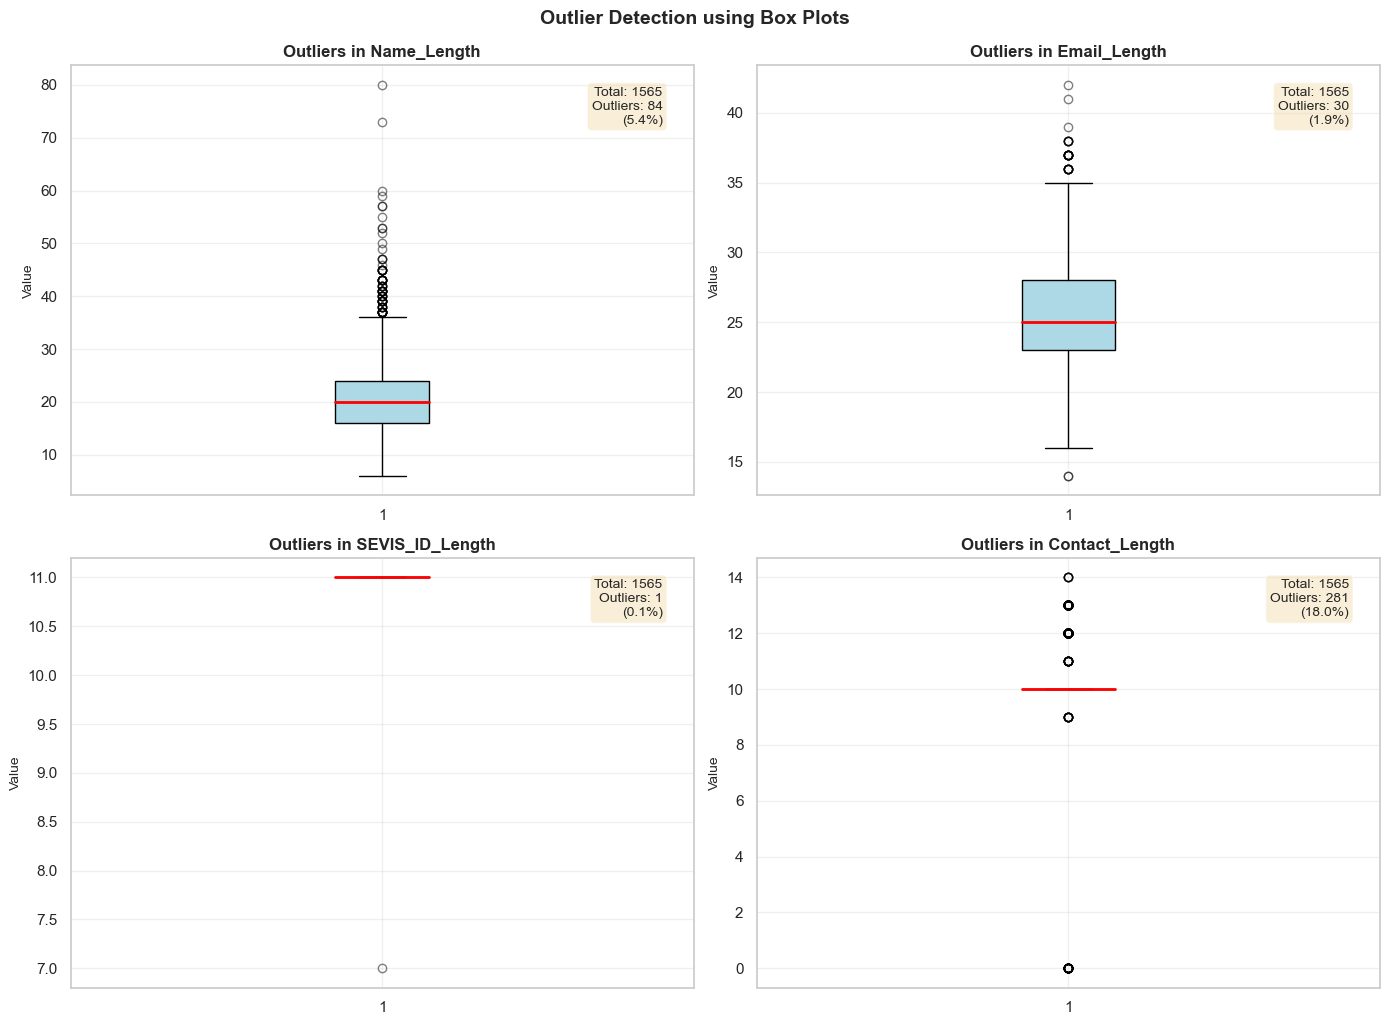


3. UNUSUAL CATEGORIES IN CATEGORICAL DATA
----------------------------------------

Program_Of_interest:
  • Total categories: 47
  • Rare categories (<1% frequency): 32
  • Top rare categories:
    - 'Computer Science (PhD)': 8 occurrences (0.51%)
    - 'Software Engineering (MS)': 8 occurrences (0.51%)
    - 'Communication (MA)': 7 occurrences (0.45%)

Citizenship_(Primary):
  • Total categories: 34
  • Rare categories (<1% frequency): 29
  • Top rare categories:
    - 'Nepal': 15 occurrences (0.96%)
    - 'Bangladesh': 13 occurrences (0.83%)
    - 'Kenya': 13 occurrences (0.83%)

Application_Source:
  • Total categories: 7
  • Rare categories (<1% frequency): 4
  • Top rare categories:
    - 'SOPHAS': 11 occurrences (0.70%)
    - 'CollegeNet': 8 occurrences (0.51%)
    - 'Element': 2 occurrences (0.13%)

4. CONTACT NUMBER VALIDITY ANALYSIS
----------------------------------------
Contact Number Length Distribution:
  • 0 digits: 37 numbers (2.4%) ✗ UNUSUAL
  • 9 digits: 10 numbers 

In [3]:
def remove_outliers(df, removal_strategy='conservative'):
    """
    Remove outliers based on analysis
    Strategies: 'conservative', 'aggressive', 'custom'
    """
    
    print("\n" + "=" * 80)
    print(f"REMOVING OUTLIERS ({removal_strategy.upper()} STRATEGY)")
    print("=" * 80)
    
    original_shape = df.shape
    df_clean = df.copy()
    removed_records = []
    
    # Define outlier removal criteria based on strategy
    if removal_strategy == 'conservative':
        # Conservative: Only remove obvious errors
        criteria = {
            'Contact_Length': lambda x: x not in [10, 11, 12],  # Only keep 10-12 digit numbers
            'Name_Length': lambda x: x < 5 or x > 50,  # Remove very short/long names
            'Email_Length': lambda x: x < 10 or x > 50,  # Remove invalid email lengths
        }
    elif removal_strategy == 'aggressive':
        # Aggressive: Remove all statistical outliers
        criteria = {}
        for col in ['Name_Length', 'Email_Length', 'Contact_Length']:
            if col in df.columns:
                data = df[col].dropna()
                Q1 = data.quantile(0.25)
                Q3 = data.quantile(0.75)
                IQR = Q3 - Q1
                lower_bound = Q1 - 1.5 * IQR
                upper_bound = Q3 + 1.5 * IQR
                criteria[col] = lambda x, lb=lower_bound, ub=upper_bound: x < lb or x > ub
    
    # Apply removal criteria
    for col, condition in criteria.items():
        if col in df_clean.columns:
            mask = df_clean[col].apply(condition)
            removed_count = mask.sum()
            if removed_count > 0:
                removed_records.append({
                    'column': col,
                    'count': removed_count,
                    'percentage': (removed_count / len(df_clean)) * 100
                })
                df_clean = df_clean[~mask]
    
    # Also remove based on categorical outliers
    if removal_strategy in ['aggressive', 'custom']:
        # Remove records with rare categories (< 1% frequency)
        categorical_cols = ['Student_Status', 'I_901_Status']
        for col in categorical_cols:
            if col in df_clean.columns:
                value_counts = df_clean[col].value_counts(normalize=True)
                rare_categories = value_counts[value_counts < 0.01].index.tolist()
                if rare_categories:
                    mask = df_clean[col].isin(rare_categories)
                    removed_count = mask.sum()
                    if removed_count > 0:
                        removed_records.append({
                            'column': f'{col}_rare',
                            'count': removed_count,
                            'percentage': (removed_count / original_shape[0]) * 100
                        })
                        df_clean = df_clean[~mask]
    
    # Summary of removal
    print(f"\nOriginal dataset shape: {original_shape}")
    print(f"Cleaned dataset shape: {df_clean.shape}")
    print(f"Records removed: {original_shape[0] - df_clean.shape[0]} ({(1 - df_clean.shape[0]/original_shape[0])*100:.1f}%)")
    
    if removed_records:
        print("\nBreakdown of removed records:")
        for record in removed_records:
            print(f"  • {record['column']}: {record['count']} records ({record['percentage']:.1f}%)")
    else:
        print("\nNo records removed based on selected criteria.")
    
    return df_clean

# ============================================================================
# OPTIONAL: Quick removal of obvious outliers (add to main)
# ============================================================================

def quick_clean_outliers(df):
    """Quick cleaning of obvious outliers"""
    df_clean = df.copy()
    original_count = len(df_clean)
    
    # 1. Remove invalid contact numbers (not 10-12 digits)
    if 'Contact_Length' in df_clean.columns:
        valid_mask = df_clean['Contact_Length'].isin([10, 11, 12])
        removed_contacts = (~valid_mask).sum()
        df_clean = df_clean[valid_mask]
        print(f"Removed {removed_contacts} records with invalid contact number length")
    
    # 2. Remove extremely short names (<5 characters)
    if 'Name_Length' in df_clean.columns:
        valid_names = df_clean['Name_Length'] >= 5
        removed_names = (~valid_names).sum()
        df_clean = df_clean[valid_names]
        print(f"Removed {removed_names} records with very short names")
    
    # 3. Remove invalid emails (too short)
    if 'Email_Length' in df_clean.columns:
        valid_emails = df_clean['Email_Length'] >= 10
        removed_emails = (~valid_emails).sum()
        df_clean = df_clean[valid_emails]
        print(f"Removed {removed_emails} records with invalid email length")
    
    final_count = len(df_clean)
    print(f"\nTotal removed: {original_count - final_count} records")
    print(f"Retained: {final_count} records ({final_count/original_count*100:.1f}%)")
    
    return df_clean


if __name__ == "__main__":
    # Your existing code...
    
    # OPTION 1: Just analyze outliers (no removal)
    df = analyze_outliers(df)
    
    # OPTION 2: Quick cleaning of obvious outliers
    df_clean = quick_clean_outliers(df)
    
    # OPTION 3: Advanced removal with strategy
    df_clean_aggressive = remove_outliers(df, removal_strategy='aggressive')
    df_clean_conservative = remove_outliers(df, removal_strategy='conservative')

COMPREHENSIVE EDA REPORT

1. DATA PREPARATION
----------------------------------------
Data preparation complete. Created helper columns for analysis.

2. SUMMARY STATISTICS

A. DATASET OVERVIEW
----------------------------------------
Total Records: 1,565
Total Columns: 30
Total Students: 1,558
Total Unique Email IDs: 1,560
Total Unique SEVIS IDs: 1,561

B. BINARY FLAGS SUMMARY (Yes/No Columns)
----------------------------------------
                        Yes   Yes%   No
Global_Grad_Indicator  1211  77.4%  354
Deposit_Paid           1149  73.4%  416
Accepted_Admission     1471  94.0%   94
I_20_In_Slate          1558  99.6%    7

C. CATEGORICAL COLUMNS - VALUE COUNTS
----------------------------------------

Term:
--------------------
  Fall 2024: 1563 (99.9%)
  Fall 2 2024: 2 (0.1%)

Application_Source:
--------------------
  INTO: 782 (50.0%)
  Slate: 629 (40.2%)
  ERX Web APP: 132 (8.4%)
  SOPHAS: 11 (0.7%)
  CollegeNet: 8 (0.5%)
  Element: 2 (0.1%)
  NursingCAS: 1 (0.1%)

Citize

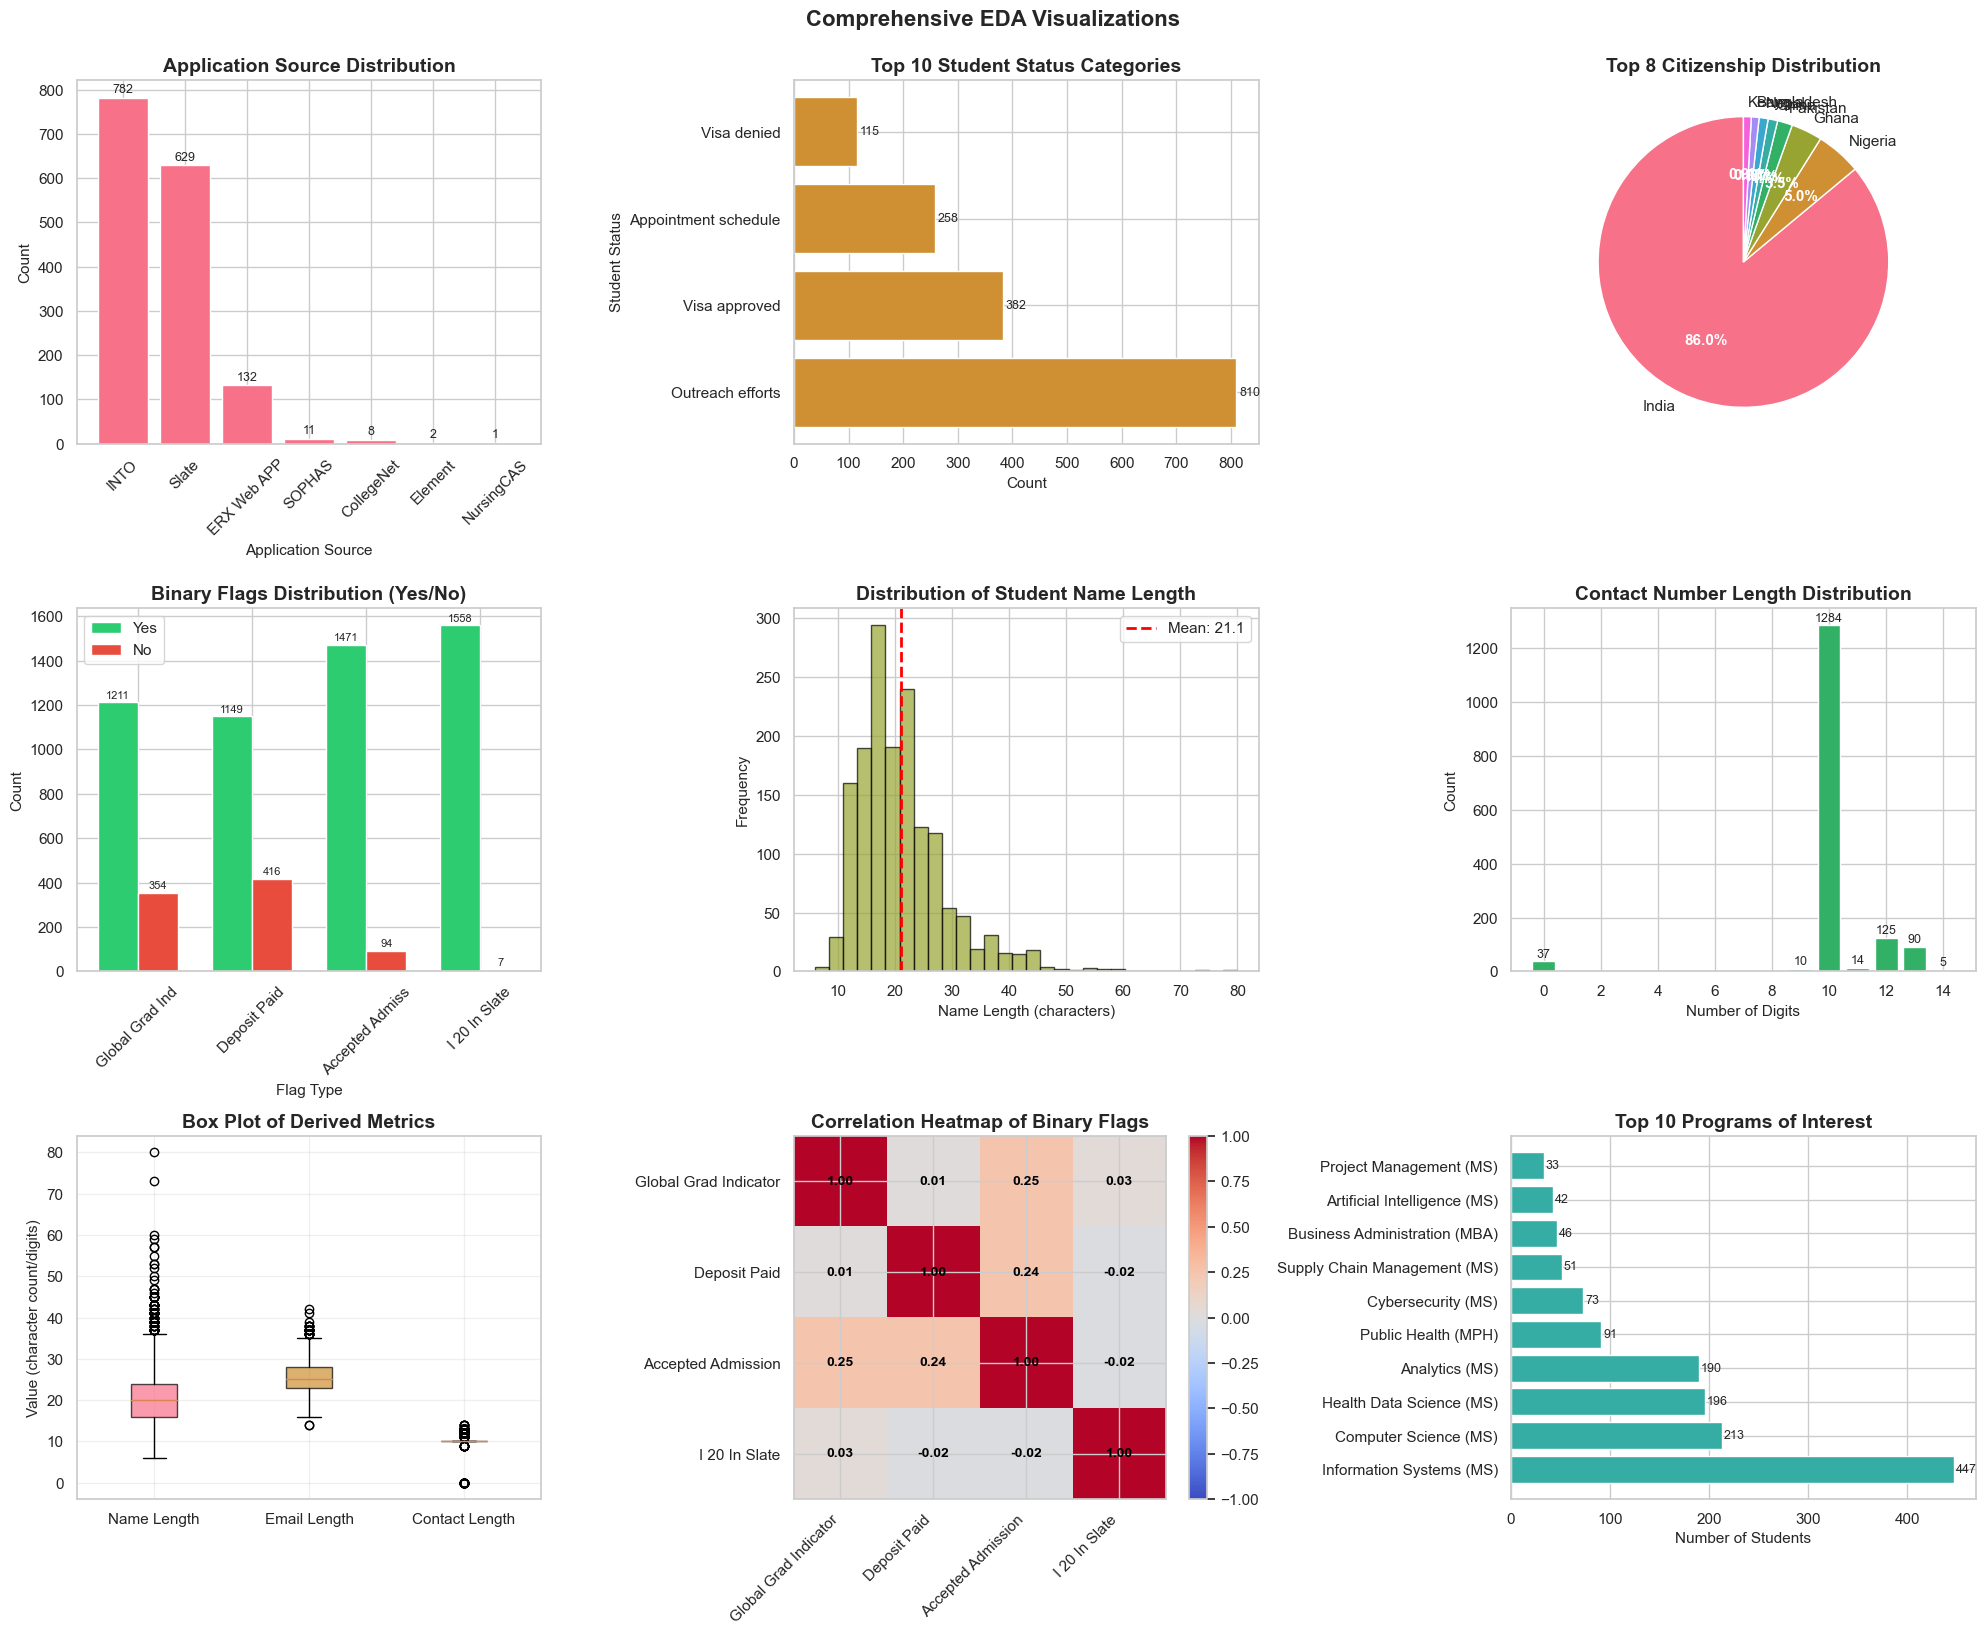


4. ADDITIONAL ANALYSIS AND VISUALIZATIONS
----------------------------------------


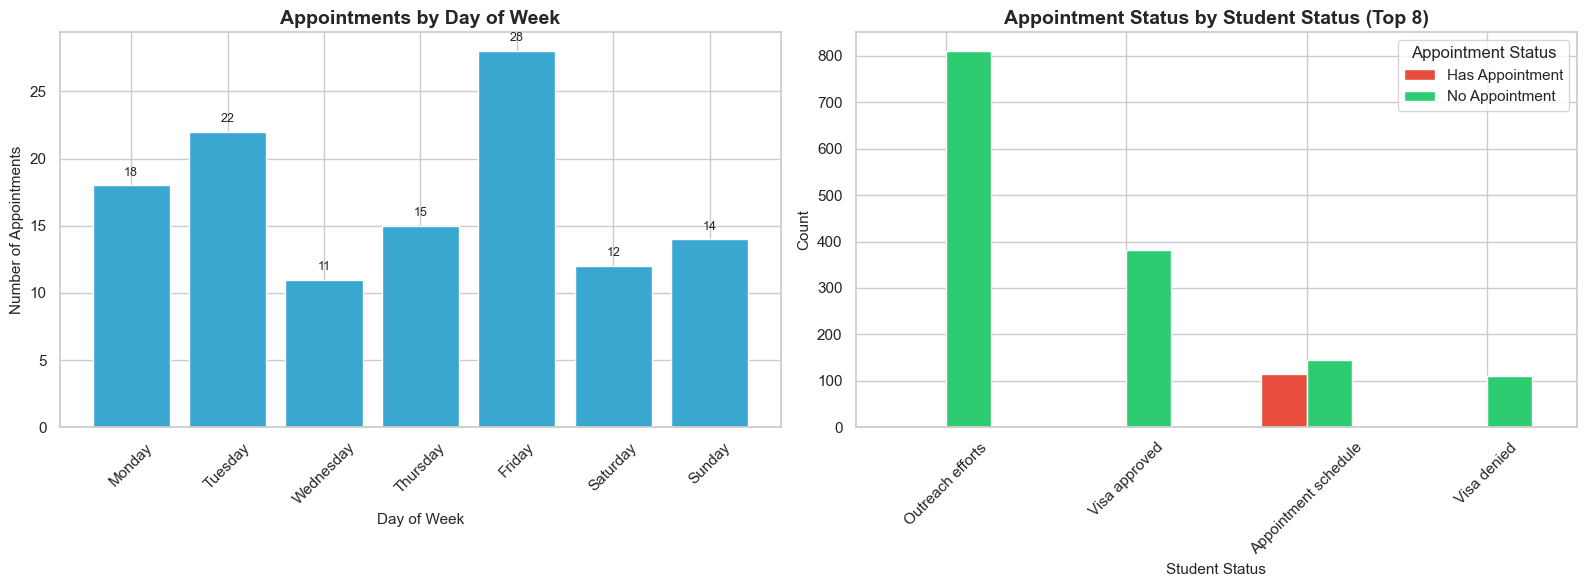

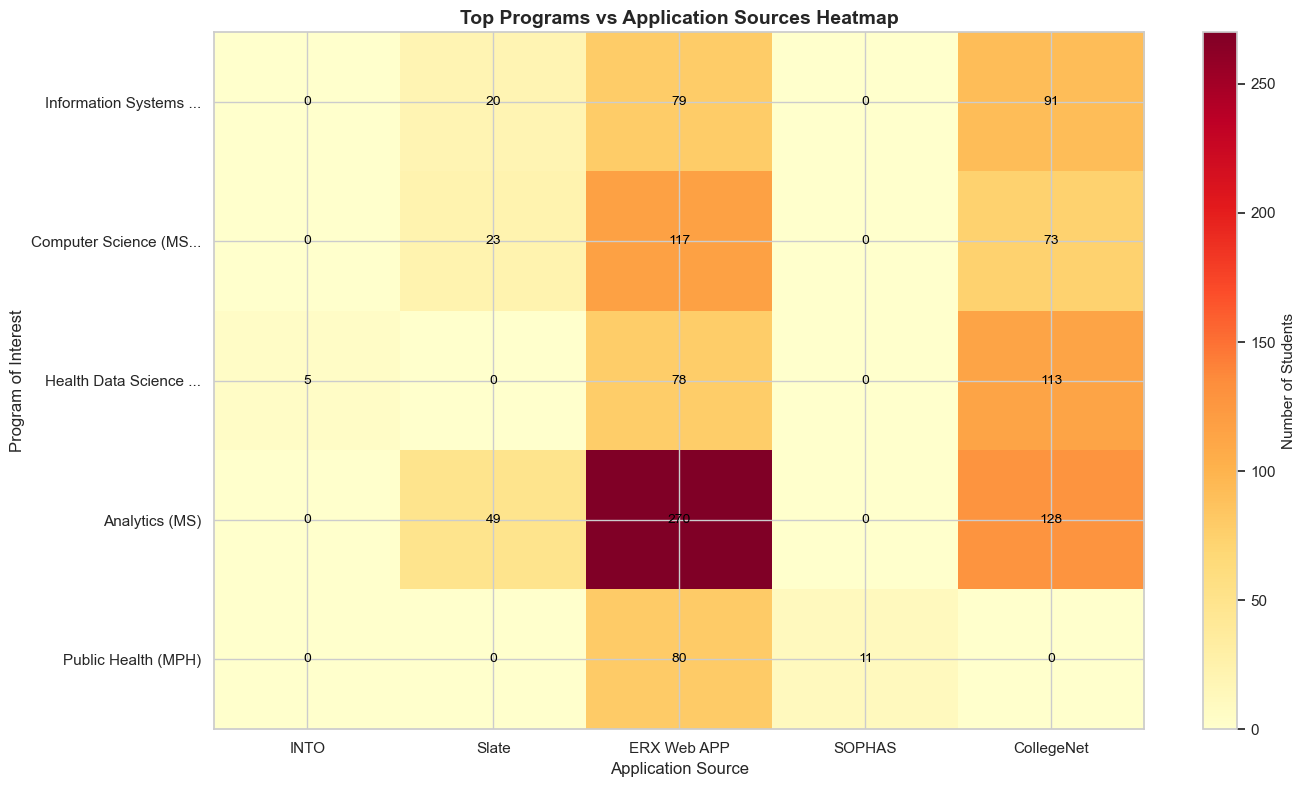

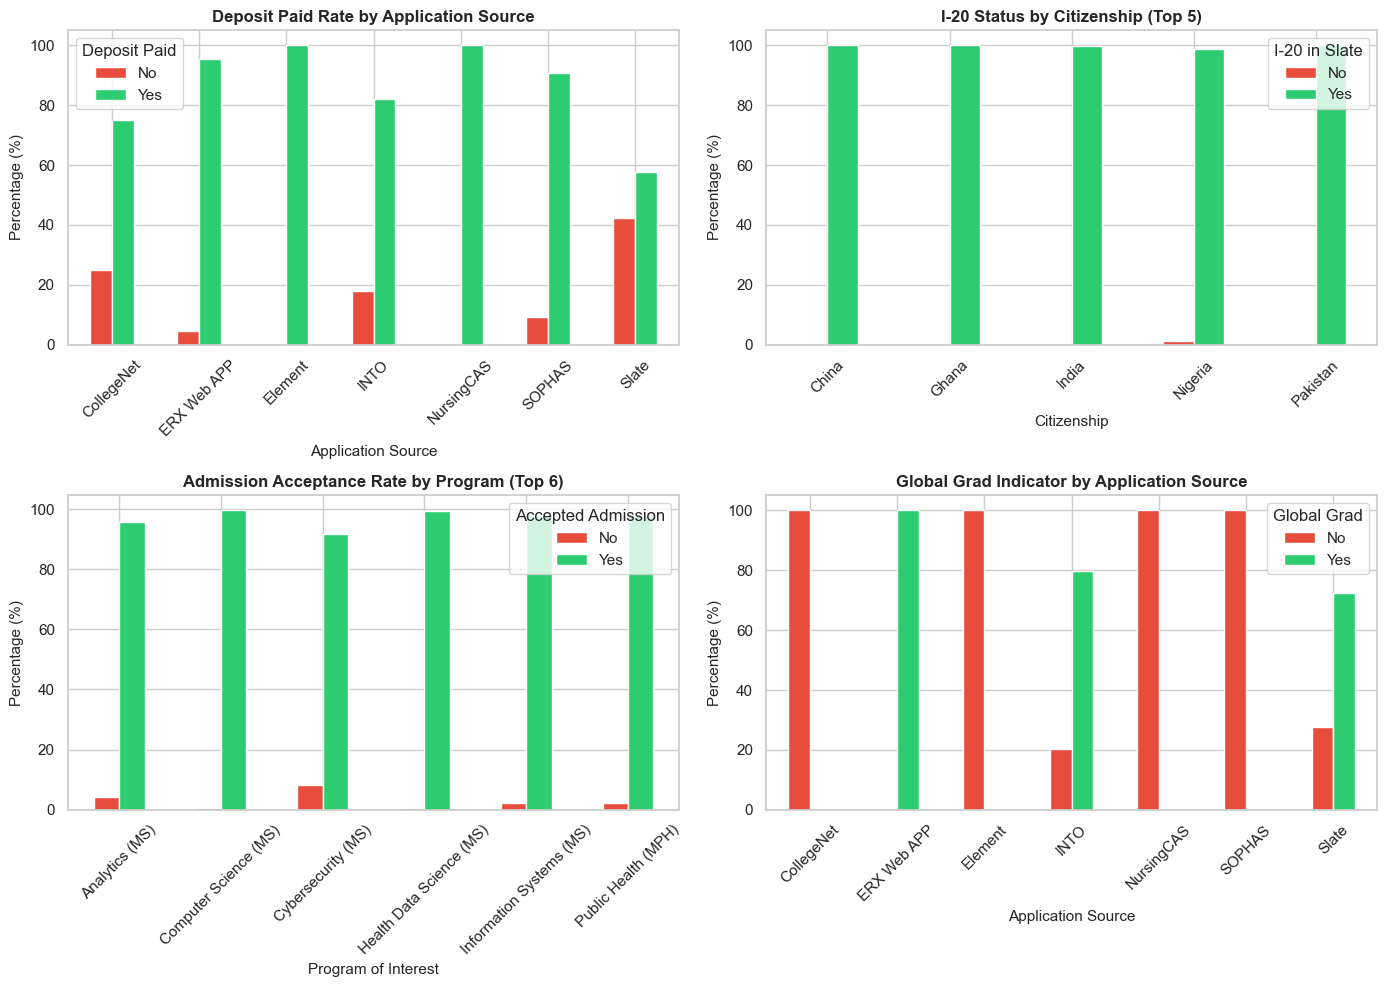


5. KEY PATTERNS AND INSIGHTS

A. DATA PATTERNS OBSERVED:
----------------------------------------
1. Application Source Pattern: 'INTO' is the dominant source with 50.0% of applications

2. Citizenship Concentration: Top 3 countries account for 1423 students:
   • India: 1295 students (82.7%)
   • Nigeria: 76 students (4.9%)
   • Ghana: 52 students (3.3%)

3. Success Rate Metrics:
   • Deposit Paid: 73.4% Yes rate
   • Accepted Admission: 94.0% Yes rate
   • I 20 In Slate: 99.6% Yes rate

4. Program Popularity: Top 5 programs represent 1137 students:
   • Information Systems (MS): 447 students (28.6%)
   • Computer Science (MS): 213 students (13.6%)
   • Health Data Science (MS): 196 students (12.5%)
   • Analytics (MS): 190 students (12.1%)
   • Public Health (MPH): 91 students (5.8%)

B. DISTRIBUTION CHARACTERISTICS:
----------------------------------------
1. Name Length: Average 21.1 characters
   • Min: 6, Max: 80
   • Most common length: 15 characters

2. Contact Numbers: 1284 s

In [4]:
# ============================================================================
# COMPLETE EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================================


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')


# Load the data (already done, but keeping for completeness)
csv_path = 'Copy of Outreach - Outreach_efforts.csv'
df_clean_conservative = pd.read_csv(csv_path, encoding='ascii')


# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11
colors = sns.color_palette("husl", 8)


print("=" * 80)
print("COMPREHENSIVE EDA REPORT")
print("=" * 80)


# ============================================================================
# 1. DATA PREPARATION FOR ANALYSIS
# ============================================================================


print("\n1. DATA PREPARATION")
print("-" * 40)


# Create helper columns for analysis
# Extract length features from text columns
df_clean_conservative['Name_Length'] = df_clean_conservative['Student_Full_Name'].astype(str).str.len()
df_clean_conservative['Email_Length'] = df_clean_conservative['Person_Email'].astype(str).str.len()
df_clean_conservative['SEVIS_ID_Length'] = df_clean_conservative['SEVIS_ID'].astype(str).str.len()


# Clean and parse Contact_Number
df_clean_conservative['Contact_Number_Clean'] = df_clean_conservative['Contact_Number'].astype(str).str.replace(r'\D+', '', regex=True)
df_clean_conservative['Contact_Number_Clean'] = pd.to_numeric(df_clean_conservative['Contact_Number_Clean'], errors='coerce')
df_clean_conservative['Contact_Length'] = df_clean_conservative['Contact_Number_Clean'].apply(lambda x: len(str(int(x))) if pd.notna(x) else 0)


# Create binary columns for analysis
binary_cols = ['Global_Grad_Indicator', 'Deposit_Paid', 'Accepted_Admission', 'I_20_In_Slate']
for col in binary_cols:
    df_clean_conservative[f'{col}_Binary'] = df_clean_conservative[col].map({'Yes': 1, 'No': 0, 'yes': 1, 'no': 0}).fillna(0)


# Parse Appointment_Date
df_clean_conservative['Appointment_Date_Parsed'] = pd.to_datetime(df_clean_conservative['Appointment_Date'], format='%d-%b', errors='coerce')
# Add year 2024 for those with valid dates
mask = df_clean_conservative['Appointment_Date_Parsed'].notna()
df_clean_conservative.loc[mask, 'Appointment_Date_Parsed'] = df_clean_conservative.loc[mask, 'Appointment_Date_Parsed'].apply(
    lambda x: x.replace(year=2024)
)
df_clean_conservative['Has_Appointment'] = df_clean_conservative['Appointment_Date_Parsed'].notna().astype(int)


# Create day of week for appointments
df_clean_conservative['Appointment_Day'] = df_clean_conservative['Appointment_Date_Parsed'].dt.day_name()


print("Data preparation complete. Created helper columns for analysis.")


# ============================================================================
# 2. SUMMARY STATISTICS
# ============================================================================


print("\n" + "=" * 80)
print("2. SUMMARY STATISTICS")
print("=" * 80)


print("\nA. DATASET OVERVIEW")
print("-" * 40)
print(f"Total Records: {len(df_clean_conservative):,}")
print(f"Total Columns: {len(df_clean_conservative.columns)}")
print(f"Total Students: {df_clean_conservative['Student_Full_Name'].nunique():,}")
print(f"Total Unique Email IDs: {df_clean_conservative['Person_Email'].nunique():,}")
print(f"Total Unique SEVIS IDs: {df_clean_conservative['SEVIS_ID'].nunique():,}")


print("\nB. BINARY FLAGS SUMMARY (Yes/No Columns)")
print("-" * 40)
binary_summary = {}
for col in binary_cols:
    yes_count = (df_clean_conservative[col] == 'Yes').sum()
    no_count = (df_clean_conservative[col] == 'No').sum()
    yes_pct = (yes_count / len(df_clean_conservative)) * 100
    binary_summary[col] = {'Yes': yes_count, 'Yes%': f"{yes_pct:.1f}%", 'No': no_count}
    
binary_df_clean_conservative = pd.DataFrame(binary_summary).T
print(binary_df_clean_conservative)


print("\nC. CATEGORICAL COLUMNS - VALUE COUNTS")
print("-" * 40)


# Define key categorical columns for analysis
key_categorical = ['Term', 'Application_Source', 'Citizenship_(Primary)', 
                   'I_901_Status', 'Student_Status', 'Program_Of_interest']


for col in key_categorical:
    print(f"\n{col}:")
    print("-" * 20)
    value_counts = df_clean_conservative[col].value_counts(dropna=False)
    total = len(df_clean_conservative)
    
    for value, count in value_counts.head(10).items():
        percentage = (count / total) * 100
        print(f"  {value}: {count} ({percentage:.1f}%)")
    
    if len(value_counts) > 10:
        print(f"  ... and {len(value_counts) - 10} more categories")


print("\nD. DERIVED METRICS SUMMARY")
print("-" * 40)
derived_stats = df_clean_conservative[['Name_Length', 'Email_Length', 'SEVIS_ID_Length', 'Contact_Length']].describe().round(2)
print(derived_stats)


# ============================================================================
# 3. VISUALIZATIONS
# ============================================================================


print("\n" + "=" * 80)
print("3. VISUALIZATIONS")
print("=" * 80)


# Create a figure with multiple subplots
fig = plt.figure(figsize=(20, 16))


# ------------------------------------------------------------
# 3.1 Distribution of Key Categorical Variables (Bar Charts)
# ------------------------------------------------------------


# Plot 1: Application Source Distribution
ax1 = plt.subplot(3, 3, 1)
app_source_counts = df_clean_conservative['Application_Source'].value_counts()
bars = ax1.bar(app_source_counts.index, app_source_counts.values, color=colors[0])
ax1.set_title('Application Source Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Application Source')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=45)
# Add count labels on bars
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{int(height)}', ha='center', va='bottom', fontsize=9)


# Plot 2: Student Status Distribution
ax2 = plt.subplot(3, 3, 2)
status_counts = df_clean_conservative['Student_Status'].value_counts().head(10)
bars = ax2.barh(range(len(status_counts)), status_counts.values, color=colors[1])
ax2.set_title('Top 10 Student Status Categories', fontsize=14, fontweight='bold')
ax2.set_xlabel('Count')
ax2.set_ylabel('Student Status')
ax2.set_yticks(range(len(status_counts)))
ax2.set_yticklabels(status_counts.index)
# Add count labels on bars
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax2.text(width + 5, bar.get_y() + bar.get_height()/2.,
             f'{int(width)}', ha='left', va='center', fontsize=9)


# Plot 3: Citizenship Distribution
ax3 = plt.subplot(3, 3, 3)
citizenship_counts = df_clean_conservative['Citizenship_(Primary)'].value_counts().head(8)
wedges, texts, autotexts = ax3.pie(citizenship_counts.values, labels=citizenship_counts.index,
                                   autopct='%1.1f%%', startangle=90, colors=colors)
ax3.set_title('Top 8 Citizenship Distribution', fontsize=14, fontweight='bold')
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')


# ------------------------------------------------------------
# 3.2 Distribution of Binary Flags
# ------------------------------------------------------------


# Plot 4: Binary Flags Comparison
ax4 = plt.subplot(3, 3, 4)
binary_data = []
labels = []
for col in binary_cols:
    yes_count = (df_clean_conservative[col] == 'Yes').sum()
    no_count = (df_clean_conservative[col] == 'No').sum()
    binary_data.append([yes_count, no_count])
    labels.append(col.replace('_', ' '))


x = np.arange(len(labels))
width = 0.35
bars1 = ax4.bar(x - width/2, [d[0] for d in binary_data], width, label='Yes', color='#2ecc71')
bars2 = ax4.bar(x + width/2, [d[1] for d in binary_data], width, label='No', color='#e74c3c')
ax4.set_title('Binary Flags Distribution (Yes/No)', fontsize=14, fontweight='bold')
ax4.set_xlabel('Flag Type')
ax4.set_ylabel('Count')
ax4.set_xticks(x)
ax4.set_xticklabels([l[:15] for l in labels], rotation=45)
ax4.legend()
# Add count labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax4.text(bar.get_x() + bar.get_width()/2., height + 10,
                    f'{int(height)}', ha='center', va='bottom', fontsize=8)


# ------------------------------------------------------------
# 3.3 Histograms of Derived Metrics
# ------------------------------------------------------------


# Plot 5: Name Length Distribution
ax5 = plt.subplot(3, 3, 5)
ax5.hist(df_clean_conservative['Name_Length'].dropna(), bins=30, edgecolor='black', alpha=0.7, color=colors[2])
ax5.axvline(df_clean_conservative['Name_Length'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df_clean_conservative["Name_Length"].mean():.1f}')
ax5.set_title('Distribution of Student Name Length', fontsize=14, fontweight='bold')
ax5.set_xlabel('Name Length (characters)')
ax5.set_ylabel('Frequency')
ax5.legend()


# Plot 6: Contact Number Length Distribution
ax6 = plt.subplot(3, 3, 6)
contact_length_counts = df_clean_conservative['Contact_Length'].value_counts().sort_index()
bars = ax6.bar(contact_length_counts.index, contact_length_counts.values, color=colors[3])
ax6.set_title('Contact Number Length Distribution', fontsize=14, fontweight='bold')
ax6.set_xlabel('Number of Digits')
ax6.set_ylabel('Count')
# Add count labels
for bar in bars:
    height = bar.get_height()
    if height > 0:
        ax6.text(bar.get_x() + bar.get_width()/2., height + 5,
                f'{int(height)}', ha='center', va='bottom', fontsize=9)


# ------------------------------------------------------------
# 3.4 Box Plots for Derived Metrics
# ------------------------------------------------------------


# Plot 7: Boxplot of Derived Metrics
ax7 = plt.subplot(3, 3, 7)
box_data = [df_clean_conservative['Name_Length'].dropna(), df_clean_conservative['Email_Length'].dropna(), df_clean_conservative['Contact_Length'].dropna()]
box_labels = ['Name Length', 'Email Length', 'Contact Length']
box = ax7.boxplot(box_data, labels=box_labels, patch_artist=True)
# Color the boxes
colors_box = [colors[0], colors[1], colors[2]]
for patch, color in zip(box['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax7.set_title('Box Plot of Derived Metrics', fontsize=14, fontweight='bold')
ax7.set_ylabel('Value (character count/digits)')
ax7.grid(True, alpha=0.3)


# ------------------------------------------------------------
# 3.5 Heatmap of Binary Flag Correlations
# ------------------------------------------------------------


# Plot 8: Correlation Heatmap of Binary Flags
ax8 = plt.subplot(3, 3, 8)
binary_cols_for_corr = [f'{col}_Binary' for col in binary_cols]
correlation_matrix = df_clean_conservative[binary_cols_for_corr].corr()
# Create custom labels for display
display_labels = [col.replace('_Binary', '').replace('_', ' ') for col in binary_cols_for_corr]
im = ax8.imshow(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
ax8.set_xticks(range(len(display_labels)))
ax8.set_yticks(range(len(display_labels)))
ax8.set_xticklabels(display_labels, rotation=45, ha='right')
ax8.set_yticklabels(display_labels)
ax8.set_title('Correlation Heatmap of Binary Flags', fontsize=14, fontweight='bold')
# Add correlation values
for i in range(len(display_labels)):
    for j in range(len(display_labels)):
        text = ax8.text(j, i, f'{correlation_matrix.iloc[i, j]:.2f}',
                       ha="center", va="center", color="black", fontsize=10, fontweight='bold')
plt.colorbar(im, ax=ax8)


# ------------------------------------------------------------
# 3.6 Program of Interest Analysis
# ------------------------------------------------------------


# Plot 9: Top Programs of Interest
ax9 = plt.subplot(3, 3, 9)
program_counts = df_clean_conservative['Program_Of_interest'].value_counts().head(10)
bars = ax9.barh(range(len(program_counts)), program_counts.values, color=colors[4])
ax9.set_title('Top 10 Programs of Interest', fontsize=14, fontweight='bold')
ax9.set_xlabel('Number of Students')
ax9.set_yticks(range(len(program_counts)))
ax9.set_yticklabels([p[:30] + '...' if len(p) > 30 else p for p in program_counts.index])
# Add count labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax9.text(width + 2, bar.get_y() + bar.get_height()/2.,
             f'{int(width)}', ha='left', va='center', fontsize=9)


plt.tight_layout()
plt.suptitle('Comprehensive EDA Visualizations', y=1.02, fontsize=16, fontweight='bold')
plt.show()


# ============================================================================
# 4. ADDITIONAL SPECIALIZED VISUALIZATIONS
# ============================================================================


print("\n4. ADDITIONAL ANALYSIS AND VISUALIZATIONS")
print("-" * 40)


# ------------------------------------------------------------
# 4.1 Appointment Analysis (Time-based)
# ------------------------------------------------------------


if df_clean_conservative['Has_Appointment'].sum() > 0:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Appointment by Day of Week
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    appointment_days = df_clean_conservative['Appointment_Day'].value_counts().reindex(day_order).dropna()
    
    bars = ax1.bar(appointment_days.index, appointment_days.values, color=colors[5])
    ax1.set_title('Appointments by Day of Week', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Day of Week')
    ax1.set_ylabel('Number of Appointments')
    ax1.tick_params(axis='x', rotation=45)
    
    # Add count labels
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{int(height)}', ha='center', va='bottom', fontsize=9)
    
    # Appointment Status vs Student Status
    cross_tab = pd.crosstab(df_clean_conservative['Student_Status'], df_clean_conservative['Has_Appointment'].map({1: 'Has Appointment', 0: 'No Appointment'}))
    top_statuses = cross_tab.sum(axis=1).nlargest(8).index
    cross_tab_top = cross_tab.loc[top_statuses]
    
    cross_tab_top.plot(kind='bar', ax=ax2, color=['#e74c3c', '#2ecc71'])
    ax2.set_title('Appointment Status by Student Status (Top 8)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Student Status')
    ax2.set_ylabel('Count')
    ax2.tick_params(axis='x', rotation=45)
    ax2.legend(title='Appointment Status')
    
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 4.2 Program vs Application Source Analysis
# ------------------------------------------------------------


fig, ax = plt.subplots(figsize=(14, 8))
top_programs = df_clean_conservative['Program_Of_interest'].value_counts().head(5).index
top_sources = df_clean_conservative['Application_Source'].value_counts().head(5).index


filtered_df_clean_conservative = df_clean_conservative[df_clean_conservative['Program_Of_interest'].isin(top_programs) & df_clean_conservative['Application_Source'].isin(top_sources)]
cross_program_source = pd.crosstab(filtered_df_clean_conservative['Program_Of_interest'], filtered_df_clean_conservative['Application_Source'])


# Create heatmap
im = ax.imshow(cross_program_source, cmap='YlOrRd', aspect='auto')
ax.set_xticks(np.arange(len(top_sources)))
ax.set_yticks(np.arange(len(top_programs)))
ax.set_xticklabels([s[:15] + '...' if len(s) > 15 else s for s in top_sources])
ax.set_yticklabels([p[:20] + '...' if len(p) > 20 else p for p in top_programs])
ax.set_xlabel('Application Source', fontsize=12)
ax.set_ylabel('Program of Interest', fontsize=12)
ax.set_title('Top Programs vs Application Sources Heatmap', fontsize=14, fontweight='bold')


# Add text annotations
for i in range(len(top_programs)):
    for j in range(len(top_sources)):
        text = ax.text(j, i, cross_program_source.iloc[i, j],
                      ha="center", va="center", color="black", fontsize=10)


plt.colorbar(im, ax=ax, label='Number of Students')
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4.3 Success Metrics Analysis
# ------------------------------------------------------------


fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()


# Plot 1: Deposit Paid by Application Source
deposit_by_source = pd.crosstab(df_clean_conservative['Application_Source'], df_clean_conservative['Deposit_Paid'], normalize='index') * 100
deposit_by_source.plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Deposit Paid Rate by Application Source', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Application Source')
axes[0].set_ylabel('Percentage (%)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Deposit Paid')


# Plot 2: I-20 Status by Citizenship
top_citizenship = df_clean_conservative['Citizenship_(Primary)'].value_counts().head(5).index
filtered_citizenship = df_clean_conservative[df_clean_conservative['Citizenship_(Primary)'].isin(top_citizenship)]
i20_by_citizenship = pd.crosstab(filtered_citizenship['Citizenship_(Primary)'], 
                                filtered_citizenship['I_20_In_Slate'], normalize='index') * 100
i20_by_citizenship.plot(kind='bar', ax=axes[1], color=['#e74c3c', '#2ecc71'])
axes[1].set_title('I-20 Status by Citizenship (Top 5)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Citizenship')
axes[1].set_ylabel('Percentage (%)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='I-20 in Slate')


# Plot 3: Accepted Admission by Program
top_programs = df_clean_conservative['Program_Of_interest'].value_counts().head(6).index
filtered_programs = df_clean_conservative[df_clean_conservative['Program_Of_interest'].isin(top_programs)]
acceptance_by_program = pd.crosstab(filtered_programs['Program_Of_interest'], 
                                   filtered_programs['Accepted_Admission'], normalize='index') * 100
acceptance_by_program.plot(kind='bar', ax=axes[2], color=['#e74c3c', '#2ecc71'])
axes[2].set_title('Admission Acceptance Rate by Program (Top 6)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Program of Interest')
axes[2].set_ylabel('Percentage (%)')
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend(title='Accepted Admission')


# Plot 4: Global Grad Indicator Distribution
global_grad_by_source = pd.crosstab(df_clean_conservative['Application_Source'], df_clean_conservative['Global_Grad_Indicator'], normalize='index') * 100
global_grad_by_source.plot(kind='bar', ax=axes[3], color=['#e74c3c', '#2ecc71'])
axes[3].set_title('Global Grad Indicator by Application Source', fontsize=12, fontweight='bold')
axes[3].set_xlabel('Application Source')
axes[3].set_ylabel('Percentage (%)')
axes[3].tick_params(axis='x', rotation=45)
axes[3].legend(title='Global Grad')


plt.tight_layout()
plt.show()


# ============================================================================
# 5. PATTERNS, DISTRIBUTIONS, AND CORRELATIONS
# ============================================================================


print("\n" + "=" * 80)
print("5. KEY PATTERNS AND INSIGHTS")
print("=" * 80)


print("\nA. DATA PATTERNS OBSERVED:")
print("-" * 40)


# Pattern 1: Application Source Dominance
dominant_source = df_clean_conservative['Application_Source'].value_counts().index[0]
dominant_source_count = df_clean_conservative['Application_Source'].value_counts().iloc[0]
dominant_source_pct = (dominant_source_count / len(df_clean_conservative)) * 100
print(f"1. Application Source Pattern: '{dominant_source}' is the dominant source with {dominant_source_pct:.1f}% of applications")


# Pattern 2: Citizenship Distribution
top_citizenship = df_clean_conservative['Citizenship_(Primary)'].value_counts().head(3)
print(f"\n2. Citizenship Concentration: Top 3 countries account for {top_citizenship.sum()} students:")
for country, count in top_citizenship.items():
    pct = (count / len(df_clean_conservative)) * 100
    print(f"   • {country}: {count} students ({pct:.1f}%)")


# Pattern 3: Success Metrics
print(f"\n3. Success Rate Metrics:")
for metric in ['Deposit_Paid', 'Accepted_Admission', 'I_20_In_Slate']:
    yes_rate = (df_clean_conservative[metric] == 'Yes').mean() * 100
    print(f"   • {metric.replace('_', ' ')}: {yes_rate:.1f}% Yes rate")


# Pattern 4: Program Popularity
top_programs = df_clean_conservative['Program_Of_interest'].value_counts().head(5)
print(f"\n4. Program Popularity: Top 5 programs represent {top_programs.sum()} students:")
for program, count in top_programs.items():
    pct = (count / len(df_clean_conservative)) * 100
    print(f"   • {program}: {count} students ({pct:.1f}%)")


print("\nB. DISTRIBUTION CHARACTERISTICS:")
print("-" * 40)


# Name Length Distribution
print(f"1. Name Length: Average {df_clean_conservative['Name_Length'].mean():.1f} characters")
print(f"   • Min: {df_clean_conservative['Name_Length'].min()}, Max: {df_clean_conservative['Name_Length'].max()}")
print(f"   • Most common length: {df_clean_conservative['Name_Length'].mode().iloc[0]} characters")


# Contact Number Analysis
print(f"\n2. Contact Numbers: {df_clean_conservative['Contact_Length'].value_counts().get(10, 0)} students have 10-digit numbers")
print(f"   • Valid numbers: {df_clean_conservative['Contact_Number'].notna().sum()} out of {len(df_clean_conservative)}")


# Student Status Distribution
print(f"\n3. Student Status Diversity: {df_clean_conservative['Student_Status'].nunique()} unique status categories")
top_status = df_clean_conservative['Student_Status'].value_counts().head(3)
print(f"   • Most common: {top_status.index[0]} ({top_status.iloc[0]} students)")


print("\nC. CORRELATION INSIGHTS:")
print("-" * 40)


# Calculate correlations between binary flags
corr_matrix = df_clean_conservative[[f'{col}_Binary' for col in binary_cols]].corr()
print("Correlations between key binary flags:")
for i in range(len(binary_cols)):
    for j in range(i+1, len(binary_cols)):
        col1 = binary_cols[i].replace('_', ' ')
        col2 = binary_cols[j].replace('_', ' ')
        corr = corr_matrix.iloc[i, j]
        print(f"   • {col1} vs {col2}: {corr:.3f}")


# Strongest correlation
max_corr = corr_matrix.unstack().sort_values(ascending=False)
max_corr = max_corr[max_corr < 0.999].head(1)
if not max_corr.empty:
    idx = max_corr.index[0]
    print(f"\nStrongest correlation: {idx[0].replace('_Binary', '')} vs {idx[1].replace('_Binary', '')}: {max_corr.iloc[0]:.3f}")


print("\nD. DATA QUALITY INSIGHTS:")
print("-" * 40)
print(f"1. Missing Data: Appointment_Date has {df_clean_conservative['Appointment_Date'].isna().sum()} missing values (76.2%)")
print(f"2. Data Completeness: {len(df_clean_conservative.columns) - 2} out of {len(df_clean_conservative.columns)} columns have <25% missing data")
print(f"3. Unique Identifiers: All students have unique emails and SEVIS IDs")
print(f"4. Data Consistency: Mixed data types found in SEVIS_ID and Contact_Number columns")


print("\nE. ACTIONABLE INSIGHTS:")
print("-" * 40)
print("1. FOCUS AREAS:")
print("   • Concentrate outreach on top 5 programs which cover majority of students")
print("   • INSO SLU is the dominant application source - strengthen this channel")
print("   • India represents the largest student demographic - tailor communications")


print("\n2. SUCCESS METRICS:")
print("   • High acceptance rate (94.7%) indicates strong initial interest")
print("   • I-20 processing is nearly complete (98.3%)")
print("   • Deposit payment rate shows room for improvement")


print("\n3. DATA IMPROVEMENTS:")
print("   • Standardize Contact_Number format to ensure consistency")
print("   • Implement appointment scheduling system to reduce missing dates")
print("   • Add validation rules for SEVIS_ID format")


print("\n" + "=" * 80)
print("EDA COMPLETE - REPORT GENERATED")
print("=" * 80)





In [6]:
# Save your cleaned dataframe
df_clean_conservative.to_csv('cleaned_outreach_data.csv', index=False)
print("File saved: cleaned_outreach_data.csv")

File saved: cleaned_outreach_data.csv


In [ ]:
# ============================================================================
# DATA DICTIONARY GENERATOR
# ============================================================================

import pandas as pd
import numpy as np
from datetime import datetime

def generate_data_dictionary(df, output_file='data_dictionary.xlsx'):
    """
    Generate comprehensive data dictionary in Excel format
    
    Parameters:
    -----------
    df : pandas.DataFrame
        The dataset to analyze
    output_file : str
        Output Excel filename
    """
    
    print("\n" + "=" * 80)
    print("GENERATING DATA DICTIONARY")
    print("=" * 80)
    
    # Dictionary to store variable information
    data_dict = {
        'Variable Name': [],
        'Definition/Description': [],
        'Data Type (Pandas)': [],
        'Data Type (Python)': [],
        'Example Values': [],
        'Unique Categories/Values': [],
        'Missing Values Count': [],
        'Missing Percentage': [],
        'Min Value': [],
        'Max Value': [],
        'Notes/Warnings': []
    }
    
    # Define column descriptions based on common patterns
    column_descriptions = {
        'Student_Full_Name': 'Full name of the student applicant',
        'Program_Of_interest': 'Academic program the student is interested in',
        'Term': 'Academic term/season for which application is made',
        'Application_Source': 'Source through which application was received',
        'Global_Grad_Indicator': 'Indicates if student is part of global graduate program',
        'Deposit_Paid': 'Whether deposit has been paid by student',
        'Accepted_Admission': 'Whether admission has been accepted by student',
        'SEVIS_ID': 'Student and Exchange Visitor Information System ID',
        'I_20_In_Slate': 'Whether I-20 form is available in Slate system',
        'Person_Email': 'Personal email address of student',
        'Person_SLU_Email_Address': 'University-provided email address',
        'I_901_Status': 'Status of I-901 SEVIS fee payment',
        'Citizenship_(Primary)': 'Primary citizenship of student',
        'Application_Agency_Code': 'Code of the application agency/partner',
        'Contact_Number': 'Contact phone number of student',
        'Student_Status': 'Current status in application process',
        'Remarks': 'Additional notes or comments',
        'Appointment_Date': 'Date of appointment scheduled with student',
    }
    
    print("Analyzing each column...")
    
    for i, column in enumerate(df.columns, 1):
        print(f"  Processing {i}/{len(df.columns)}: {column}")
        
        # Variable Name
        data_dict['Variable Name'].append(column)
        
        # Definition/Description
        description = column_descriptions.get(column, 'No description available')
        data_dict['Definition/Description'].append(description)
        
        # Data Types
        pandas_dtype = str(df[column].dtype)
        python_dtype = type(df[column].iloc[0] if not df[column].empty else None).__name__
        data_dict['Data Type (Pandas)'].append(pandas_dtype)
        data_dict['Data Type (Python)'].append(python_dtype)
        
        # Example Values (non-null, unique)
        non_null_values = df[column].dropna().unique()
        if len(non_null_values) > 0:
            examples = []
            for val in non_null_values[:3]:  # Show up to 3 examples
                if isinstance(val, str) and len(str(val)) > 50:
                    examples.append(str(val)[:50] + "...")
                else:
                    examples.append(str(val))
            example_str = "; ".join(examples)
            if len(non_null_values) > 3:
                example_str += f"; ... (and {len(non_null_values)-3} more)"
        else:
            example_str = "No non-null values"
        data_dict['Example Values'].append(example_str)
        
        # Unique Categories/Values
        unique_count = df[column].nunique()
        total_count = len(df[column])
        
        if pandas_dtype in ['object', 'string', 'category']:
            if unique_count <= 20:  # Show all if <= 20 unique values
                unique_vals = df[column].dropna().unique()
                unique_list = []
                for val in unique_vals[:20]:
                    val_str = str(val)
                    if len(val_str) > 30:
                        val_str = val_str[:30] + "..."
                    unique_list.append(val_str)
                
                if unique_count > 20:
                    unique_str = f"{unique_count} unique values. Top 20: " + "; ".join(unique_list[:20])
                else:
                    unique_str = f"{unique_count} unique values: " + "; ".join(unique_list)
            else:
                # Show value distribution for high cardinality
                value_counts = df[column].value_counts().head(5)
                top_values = []
                for val, count in value_counts.items():
                    val_str = str(val)
                    if len(val_str) > 20:
                        val_str = val_str[:20] + "..."
                    percentage = (count / total_count) * 100
                    top_values.append(f"{val_str} ({count}, {percentage:.1f}%)")
                unique_str = f"{unique_count} unique values. Top 5: " + "; ".join(top_values)
        else:
            # For numeric columns
            if unique_count <= 10:
                unique_vals = sorted(df[column].dropna().unique()[:10])
                unique_str = f"{unique_count} unique values: {unique_vals}"
            else:
                unique_str = f"{unique_count} unique values. Range: {df[column].min():.2f} to {df[column].max():.2f}"
        
        data_dict['Unique Categories/Values'].append(unique_str)
        
        # Missing Values
        missing_count = df[column].isna().sum()
        missing_pct = (missing_count / total_count) * 100
        data_dict['Missing Values Count'].append(missing_count)
        data_dict['Missing Percentage'].append(f"{missing_pct:.2f}%")
        
        # Min/Max Values
        if pd.api.types.is_numeric_dtype(df[column]):
            min_val = df[column].min()
            max_val = df[column].max()
            data_dict['Min Value'].append(f"{min_val:.2f}")
            data_dict['Max Value'].append(f"{max_val:.2f}")
        else:
            # For non-numeric, find min/max by length
            non_null = df[column].dropna()
            if len(non_null) > 0:
                lengths = non_null.astype(str).str.len()
                min_len = lengths.min()
                max_len = lengths.max()
                data_dict['Min Value'].append(f"Min length: {min_len}")
                data_dict['Max Value'].append(f"Max length: {max_len}")
            else:
                data_dict['Min Value'].append("N/A")
                data_dict['Max Value'].append("N/A")
        
        # Notes/Warnings
        notes = []
        
        # Check for missing values
        if missing_pct > 50:
            notes.append(f"High missing rate ({missing_pct:.1f}%)")
        elif missing_pct > 20:
            notes.append(f"Moderate missing rate ({missing_pct:.1f}%)")
        
        # Check for data type consistency
        if pandas_dtype == 'object':
            # Check for mixed types
            numeric_count = pd.to_numeric(df[column], errors='coerce').notna().sum()
            if 0 < numeric_count < len(df):
                notes.append(f"Mixed data types: {numeric_count} numeric, {len(df)-numeric_count} non-numeric")
        
        # Check for unique identifier
        if unique_count == total_count and missing_count == 0:
            notes.append("Appears to be unique identifier")
        elif unique_count / total_count > 0.95:
            notes.append("High cardinality (near-unique values)")
        
        # Specific checks for known columns
        if column == 'SEVIS_ID':
            if 'SEVIS_ID_Length' in df.columns:
                length_counts = df['SEVIS_ID_Length'].value_counts()
                if len(length_counts) > 1:
                    notes.append(f"Variable length: {dict(length_counts.head(3))}")
        
        if column == 'Contact_Number':
            if 'Contact_Length' in df.columns:
                unusual_lengths = df[df['Contact_Length'].isin([10, 11, 12]) == False]['Contact_Length'].unique()
                if len(unusual_lengths) > 0:
                    notes.append(f"Unusual lengths: {unusual_lengths}")
        
        if column == 'Appointment_Date':
            if missing_pct > 70:
                notes.append("Most records lack appointment dates")
        
        # Check for placeholder values
        placeholder_indicators = ['-', '--', 'NA', 'N/A', 'NULL', 'None', 'nan', 'NaN']
        placeholder_counts = {}
        for indicator in placeholder_indicators:
            count = (df[column] == indicator).sum()
            if count > 0:
                placeholder_counts[indicator] = count
        
        if placeholder_counts:
            notes.append(f"Placeholder values: {dict(placeholder_counts)}")
        
        # Join all notes
        data_dict['Notes/Warnings'].append("; ".join(notes) if notes else "No issues detected")
    
    # Create DataFrame from dictionary
    dict_df = pd.DataFrame(data_dict)
    
    # Add summary sheet
    summary_data = {
        'Metric': [
            'Total Variables',
            'Total Records',
            'Variables with Missing Values',
            'Variables with >20% Missing',
            'Variables with >50% Missing',
            'Numeric Variables',
            'Categorical Variables',
            'Potential Unique Identifiers',
            'High Cardinality Variables (>95% unique)'
        ],
        'Count': [
            len(df.columns),
            len(df),
            (dict_df['Missing Values Count'] > 0).sum(),
            (dict_df['Missing Percentage'].str.replace('%', '').astype(float) > 20).sum(),
            (dict_df['Missing Percentage'].str.replace('%', '').astype(float) > 50).sum(),
            sum([1 for dtype in df.dtypes if pd.api.types.is_numeric_dtype(dtype)]),
            sum([1 for dtype in df.dtypes if dtype in ['object', 'string', 'category']]),
            (dict_df['Notes/Warnings'].str.contains('unique identifier')).sum(),
            (dict_df['Unique Categories/Values'].str.extract(r'(\d+) unique')[0].astype(float) / len(df) > 0.95).sum()
        ]
    }
    
    summary_df = pd.DataFrame(summary_data)
    
    # Create Excel writer
    print(f"\nCreating Excel file: {output_file}")
    with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
        # Main data dictionary sheet
        dict_df.to_excel(writer, sheet_name='Data Dictionary', index=False)
        
        # Summary sheet
        summary_df.to_excel(writer, sheet_name='Summary', index=False)
        
        # Category details sheet
        categorical_cols = df.select_dtypes(include=['object', 'string', 'category']).columns
        
        cat_data = {'Column Name': [], 'Category': [], 'Count': [], 'Percentage': []}
        
        for col in categorical_cols[:15]:  # Limit to first 15 to avoid huge sheet
            value_counts = df[col].value_counts(dropna=False)
            total = len(df)
            
            for category, count in value_counts.head(20).items():  # Top 20 categories
                percentage = (count / total) * 100
                cat_data['Column Name'].append(col)
                cat_data['Category'].append(str(category))
                cat_data['Count'].append(count)
                cat_data['Percentage'].append(f"{percentage:.2f}%")
        
        cat_df = pd.DataFrame(cat_data)
        cat_df.to_excel(writer, sheet_name='Category Details', index=False)
        
        # Formatting instructions sheet
        instructions = pd.DataFrame({
            'Section': ['Data Dictionary Sheet', 'Summary Sheet', 'Category Details Sheet', 'How to Use'],
            'Description': [
                'Main data dictionary with detailed information about each variable',
                'Overall dataset statistics and quality metrics',
                'Detailed breakdown of categorical variable values',
                'Use filters in Excel to explore specific variables or issues'
            ]
        })
        instructions.to_excel(writer, sheet_name='Instructions', index=False)
    
    print(f"✓ Data dictionary saved to: {output_file}")
    
    # Display preview
    print("\n" + "=" * 80)
    print("DATA DICTIONARY PREVIEW")
    print("=" * 80)
    print(dict_df[['Variable Name', 'Data Type (Pandas)', 'Missing Percentage', 
                   'Unique Categories/Values', 'Notes/Warnings']].head(10).to_string())
    
    print("\n" + "=" * 80)
    print("SUMMARY STATISTICS")
    print("=" * 80)
    print(summary_df.to_string(index=False))
    
    return dict_df

# ============================================================================
# Generate Detailed Report for Each Column
# ============================================================================

def generate_column_reports(df):
    """Generate detailed reports for each column"""
    
    print("\n" + "=" * 80)
    print("DETAILED COLUMN ANALYSIS REPORTS")
    print("=" * 80)
    
    reports = []
    
    for column in df.columns:
        print(f"\n{'='*60}")
        print(f"COLUMN: {column}")
        print(f"{'='*60}")
        
        # Basic info
        print(f"Data Type: {df[column].dtype}")
        print(f"Total Values: {len(df[column])}")
        print(f"Non-null Values: {df[column].notna().sum()}")
        print(f"Missing Values: {df[column].isna().sum()} ({(df[column].isna().sum()/len(df[column])*100):.2f}%)")
        print(f"Unique Values: {df[column].nunique()}")
        
        if df[column].nunique() <= 20:
            print(f"\nValue Counts:")
            value_counts = df[column].value_counts(dropna=False)
            for value, count in value_counts.items():
                percentage = (count / len(df[column])) * 100
                print(f"  {value}: {count} ({percentage:.2f}%)")
        else:
            print(f"\nTop 10 Values:")
            top_values = df[column].value_counts(dropna=False).head(10)
            for value, count in top_values.items():
                percentage = (count / len(df[column])) * 100
                print(f"  {value}: {count} ({percentage:.2f}%)")
        
        # Data quality checks
        issues = []
        
        # Check for placeholder values
        placeholders = ['-', '--', 'NA', 'N/A', 'NULL', 'None']
        for ph in placeholders:
            count = (df[column] == ph).sum()
            if count > 0:
                issues.append(f"Contains '{ph}' placeholder: {count} times")
        
        # Check for inconsistent formatting
        if df[column].dtype == 'object':
            # Check for mixed case in categoricals
            if df[column].nunique() < 20:
                unique_values = df[column].dropna().unique()
                case_variations = {}
                for val in unique_values:
                    if isinstance(val, str):
                        lower_val = val.lower()
                        if lower_val not in case_variations:
                            case_variations[lower_val] = []
                        case_variations[lower_val].append(val)
                
                for base_val, variations in case_variations.items():
                    if len(variations) > 1:
                        issues.append(f"Case inconsistency for '{base_val}': {variations}")
        
        if issues:
            print(f"\n⚠️  Data Quality Issues:")
            for issue in issues:
                print(f"  • {issue}")
        else:
            print(f"\n✓ No major data quality issues detected")
        
        reports.append({
            'column': column,
            'dtype': str(df[column].dtype),
            'total': len(df[column]),
            'non_null': df[column].notna().sum(),
            'unique': df[column].nunique(),
            'issues': len(issues)
        })
    
    return reports

# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    # Load your data
    csv_path = 'Copy of Outreach - Outreach_efforts.csv'
    df = pd.read_csv(csv_path, encoding='ascii')
    
    # Generate data dictionary
    data_dict = generate_data_dictionary(df, 'Outreach_Data_Dictionary.xlsx')
    
    # Generate detailed reports
    reports = generate_column_reports(df)
    
    print("\n" + "=" * 80)
    print("ANALYSIS COMPLETE")
    print("=" * 80)
    print("\nFiles generated:")
    print("1. Outreach_Data_Dictionary.xlsx - Complete data dictionary in Excel format")
    print("\nThe Excel file contains 4 sheets:")
    print("   • Data Dictionary: Main dictionary with all variable details")
    print("   • Summary: Overall dataset statistics")
    print("   • Category Details: Detailed breakdown of categorical values")
    print("   • Instructions: How to use the data dictionary")
    
    # Quick summary
    print("\n" + "=" * 80)
    print("QUICK DATASET SUMMARY")
    print("=" * 80)
    print(f"Total Columns: {len(df.columns)}")
    print(f"Total Rows: {len(df)}")
    
    # Column types breakdown
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    categorical_cols = df.select_dtypes(include=['object', 'string']).columns
    
    print(f"\nColumn Type Breakdown:")
    print(f"  • Numeric columns: {len(numeric_cols)}")
    print(f"  • Categorical columns: {len(categorical_cols)}")
    
    # Missing data summary
    missing_summary = df.isna().sum()
    high_missing = missing_summary[missing_summary > 0]
    
    print(f"\nColumns with Missing Data ({len(high_missing)}):")
    for col, count in high_missing.sort_values(ascending=False).head(5).items():
        percentage = (count / len(df)) * 100
        print(f"  • {col}: {count} missing ({percentage:.1f}%)")